In [ ]:
import numpy as np
from scipy.stats import uniform
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import os
import pandas as pd
import random
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
from numpy.polynomial.legendre import Legendre

In [2]:
version = 'vpce1.1'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   
# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

LF_noise = 0.028



In [3]:
# Generate synthetic data
np.random.seed(42)
n_samples = 50


In [4]:
data=pd.read_csv("./in/hf_validation_data_v1.3.csv")
x_data = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_data = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

In [5]:
# Generate a list of integers from 5 to 15
x_test=[]
y_test_true=[]
indices_hf = random.sample(range(0, len(x_data)), len(x_data)-n_samples)
x_train=x_data.copy()
y_train_true=y_data.copy()
for index in sorted(indices_hf, reverse=True):
    x_train.pop(index)
    y_train_true.pop(index)
    x_test.append(x_data[index])
    y_test_true.append(y_data[index])

x_test=np.array(x_test)
y_test_true=np.array(y_test_true)
x_train=np.array(x_train)
y_train_true=np.array(y_train_true)



In [ ]:


def multivariate_legendre_basis(x_data, degree):
    """
    Generate the multivariate Legendre basis for multi-dimensional inputs.
    
    Parameters:
        x_data (ndarray): Input data of shape (n_samples, n_dim).
        degree (int): Maximum polynomial degree.
    
    Returns:
        basis_matrix (ndarray): Shape (n_samples, n_terms).
    """
    n_samples, n_dim = x_data.shape
    terms = []
    
    # Generate all combinations of terms up to the given degree
    for deg in range(degree + 1):
        for combo in combinations_with_replacement(range(n_dim), deg):
            terms.append(combo)

    # Evaluate each term for all samples
    basis_matrix = np.zeros((n_samples, len(terms)))
    for i, term in enumerate(terms):
        poly = np.prod([Legendre.basis(1)(x_data[:, dim]) for dim in term], axis=0)
        basis_matrix[:, i] = poly

    return basis_matrix

In [1]:
# Define degree of PCE
degree = 1
basis_matrix = multivariate_legendre_basis(x_train, degree)  # Shape: (100, 3)

# Bayesian model for PCE
with pm.Model() as model:
    # Priors for coefficients
    coeffs = pm.Normal("coeffs", mu=0, sigma=20, shape=basis_matrix.shape[1])
    
    # Prediction
    y_pred = pm.Deterministic("y_pred", pm.math.dot(basis_matrix, coeffs))
    
    # Likelihood
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    y_like = pm.Normal("y_like", mu=y_pred, sigma=sigma, observed=y_train_true)
    
    # Inference
    trace = pm.sample(10000, tune=1000, target_accept=0.95, return_inferencedata=True, progressbar=True)
    #trace = pm.sample(5000, return_inferencedata=True, progressbar=True)

NameError: name 'multivariate_legendre_basis' is not defined

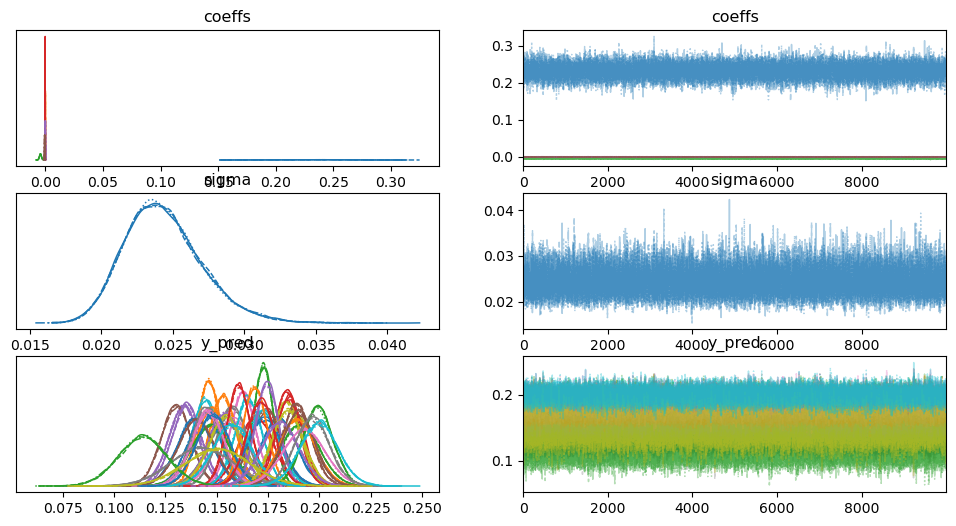

Sampling: []


/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/pymc-env/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [9]:

# Analyze results
az.plot_trace(trace)
plt.show()

# Posterior predictive samples
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_pred"])



In [ ]:
# Transpose basis_matrix to ensure proper dot product shape
basis_matrix = multivariate_legendre_basis(x_test, degree=degree)  # Shape: (100, 56)
coeff_samples = trace.posterior["coeffs"].values
# Flatten coeff_samples to combine chains and draws
coeff_samples_flat = coeff_samples.reshape(-1, coeff_samples.shape[-1])  # Shape: (4000, 56)
y_pred_samples = np.dot(coeff_samples_flat, basis_matrix.T)  # Shape: (4000, 100)


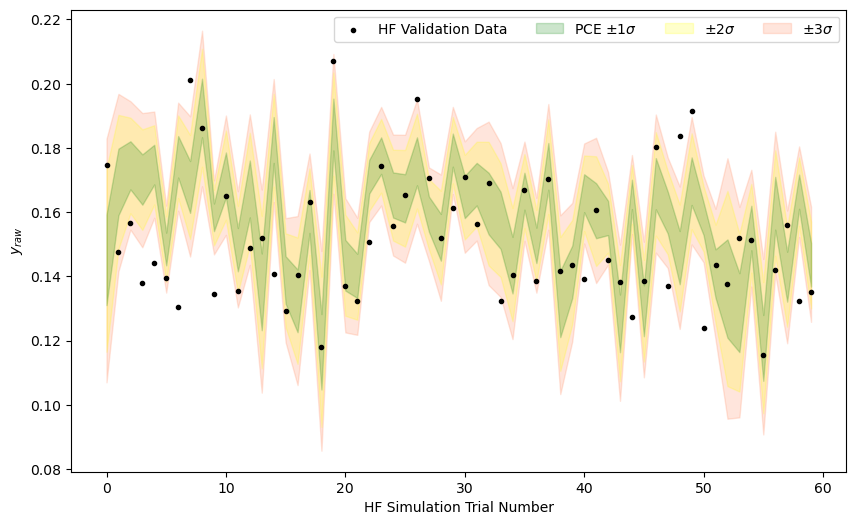

In [13]:
# Generate sample indices
sample_numbers = np.arange(len(y_test_true))  # Shape: (n_samples,)

# Plot observed vs. predicted
plt.figure(figsize=(10, 6))
plt.fill_between(
    sample_numbers,
    np.percentile(y_pred_samples, 0.5, axis=0),
    np.percentile(y_pred_samples, 99.5, axis=0),
    color="coral", alpha=0.2, label=r'$\pm 3\sigma$'
)
plt.fill_between(
    sample_numbers,
    np.percentile(y_pred_samples, 2.5, axis=0),
    np.percentile(y_pred_samples, 97.5, axis=0),
    color="yellow", alpha=0.2, label=r'$\pm 2\sigma$'
)
plt.fill_between(
    sample_numbers,
    np.percentile(y_pred_samples, 16, axis=0),
    np.percentile(y_pred_samples, 84, axis=0),
    color="green", alpha=0.2, label=r'PCE $\pm 1\sigma$'
)
plt.xlabel('HF Simulation Trial Number')
plt.ylabel(r'$y_{raw}$')
#plt.yscale('log')
plt.scatter(sample_numbers, y_test_true,marker='.',label="HF Validation Data", color="black")
#plt.scatter(sample_numbers, np.mean(y_pred_samples, axis=0),label="Predicted", color="red")

handles, labels = plt.gca().get_legend_handles_labels()
order = [3,2,1,0]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
#plt.savefig(f'out/{version}/model-validation_{version}.pdf')
plt.show()

In [14]:
counter_1sigma = 0
counter_2sigma = 0
counter_3sigma = 0
y_pred=np.mean(y_pred_samples, axis=0)
y_1sigma_low = np.percentile(y_pred_samples, 16, axis=0)
y_1sigma_high = np.percentile(y_pred_samples, 84, axis=0)
y_2sigma_low = np.percentile(y_pred_samples, 2.5, axis=0)
y_2sigma_high = np.percentile(y_pred_samples, 97.5, axis=0)
y_3sigma_low = np.percentile(y_pred_samples, 0.5, axis=0)
y_3sigma_high = np.percentile(y_pred_samples, 99.5, axis=0)
for i in range(len(y_test_true)):
        if (y_test_true[i] <= y_1sigma_high[i]) and (y_test_true[i] >= y_1sigma_low[i]):
                counter_1sigma += 1

        if (y_test_true[i] <= y_2sigma_high[i]) and (y_test_true[i] >= y_2sigma_low[i]):
                counter_2sigma += 1

        if (y_test_true[i] <= y_3sigma_high[i]) and (y_test_true[i] >= y_3sigma_low[i]):
                counter_3sigma += 1

        percentage_1sigma=counter_1sigma/len(y_test_true)*100.
        percentage_2sigma=counter_2sigma/len(y_test_true)*100.
        percentage_3sigma=counter_3sigma/len(y_test_true)*100.
print("1 sigma: ", percentage_1sigma," %" )
print("2 sigma: ", percentage_2sigma," %" )
print("3 sigma: ", percentage_3sigma," %" )

1 sigma:  35.0  %
2 sigma:  56.666666666666664  %
3 sigma:  71.66666666666667  %


In [ ]:

MSE=0
NMSE=0
MAE=0
MSSE=0

for i in range(len(y_test_true)):
        MAE +=np.abs(y_test_true[i]-y_pred[i])
        MSE +=pow(y_test_true[i]-y_pred[i],2)
        print(pow(y_test_true[i]-y_pred[i],2))
        y_std=y_1sigma_high[i]-y_1sigma_low[i]
        NMSE +=np.abs((y_test_true[i]-y_pred[i])/y_std)
        MSSE +=pow((y_test_true[i]-y_pred[i])/y_std,2)

MAE=MAE/len(y_test_true)
mse = mean_squared_error(y_test_true,y_pred, squared=True)
NMSE=NMSE/len(y_test_true)
MSSE=MSSE/len(y_test_true)
print(MSE,len(y_test_true))
MSE=MSE/len(y_test_true)
means = [percentage_1sigma,percentage_2sigma,percentage_3sigma,MAE,NMSE,MSE,MSSE]
print(f"B-PCE & {n_samples} & 0 & {''.join([f'{x:.3f} & ' for x in means])} \\\ \hline\n")


[0.1746 0.1477 0.1566 0.138  0.1443 0.1395 0.1305 0.2011 0.1863 0.1346
 0.1651 0.1356 0.1488 0.152  0.1409 0.1294 0.1404 0.1633 0.1181 0.2071
 0.137  0.1324 0.1506 0.1745 0.1558 0.1654 0.1954 0.1706 0.1519 0.1614
 0.1711 0.1563 0.169  0.1325 0.1405 0.167  0.1386 0.1704 0.1417 0.1435
 0.1392 0.1606 0.1452 0.1383 0.1274 0.1385 0.1802 0.1371 0.1837 0.1914
 0.1239 0.1435 0.1376 0.1519 0.1515 0.1155 0.1419 0.156  0.1325 0.1351] [0.14517799 0.16943168 0.17456561 0.17016297 0.17482978 0.14856187
 0.17725386 0.16788329 0.19246202 0.15842512 0.17155229 0.14837006
 0.1672342  0.13516307 0.18249224 0.13889476 0.13239563 0.16024748
 0.11655784 0.18735077 0.14346947 0.14019533 0.17104966 0.17763289
 0.16534652 0.16432682 0.17584635 0.1594189  0.15220055 0.17934172
 0.16470525 0.16874811 0.16267847 0.15749743 0.14356449 0.16656888
 0.14968894 0.17428779 0.13147624 0.14144211 0.16592612 0.16044593
 0.15821329 0.12541496 0.16556445 0.12931976 0.16890103 0.1599021
 0.14588429 0.16967856 0.15795122 0.14